In [1]:
from torchmetrics.classification import ConfusionMatrix, F1Score, AveragePrecision, Dice
import torch
from monai.metrics import DiceMetric

In [2]:
#create y_true
y_true = torch.rand((100,1,16,16,16))

In [3]:
y_true.shape

torch.Size([100, 1, 16, 16, 16])

In [3]:


#create y_pred by randomly swapping x% of y_true values
y_pred = y_true.detach().clone()
num_elements = y_true.numel()
num_samples = int(num_elements * 0.3)  # x% of the elements
#swap randomly chosen indices
idxs = torch.randperm(num_elements)[:num_samples]
idxs = torch.unravel_index(idxs,shape=y_true.shape)
y_pred[idxs] = 1 - y_pred[idxs]


In [4]:
y_true = y_true > 0.7


In [5]:
y_pred = y_pred > 0.7

In [ ]:
dice_metric_batch = DiceMetric(include_background=True, reduction="mean_batch", ignore_empty=False)


In [6]:
#compute score of entire dataset
f1 = F1Score(task='binary',num_classes=2)
f1(y_pred, y_true)

tensor(0.8024)

In [54]:
y_true = (
    y_true.permute(0, 2, 3, 4, 1)
    .contiguous()
    .view(-1, 1)
)
y_pred = (
    y_pred.permute(0, 2, 3, 4, 1)
    .contiguous()
    .view(-1, 1)
)

In [39]:
y_true

tensor([[ True],
        [ True],
        [ True],
        ...,
        [False],
        [False],
        [ True]])

In [7]:
y_pred.shape

torch.Size([100, 1, 4, 4, 4])

In [8]:
#compute score of entire dataset
cm = ConfusionMatrix(task='binary',num_classes=2)
cm(y_pred, y_true)

tensor([[4094,  359],
        [ 402, 1545]])

In [9]:
from src.utils.loss_metrics import compute_confusion_matrix_metric
compute_confusion_matrix_metric('f1',cm.confmat.flatten())

/work/scratch/sanyal/miniconda3/envs/bratseg/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tensor([0.8024])

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

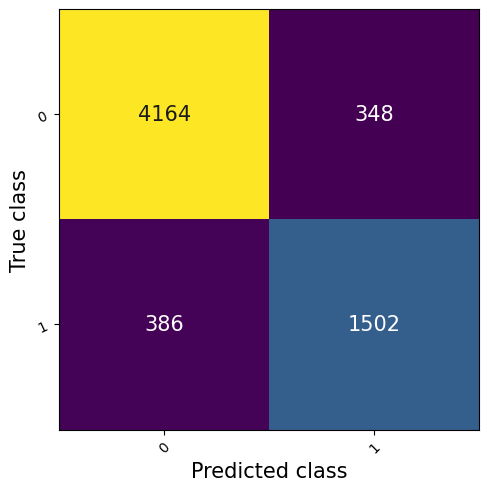

In [18]:
cm.plot()

In [14]:
metrics_names=['f1', 'ap', 'aucroc', 'balanced_accuracy', 'precision', 'recall', 'specificity', 'mcc']
other_metrics = {patch_size: {metric: None for metric in metrics_names} for patch_size in (16,32)}

In [15]:
other_metrics

{16: {'f1': None,
  'ap': None,
  'aucroc': None,
  'balanced_accuracy': None,
  'precision': None,
  'recall': None,
  'specificity': None,
  'mcc': None},
 32: {'f1': None,
  'ap': None,
  'aucroc': None,
  'balanced_accuracy': None,
  'precision': None,
  'recall': None,
  'specificity': None,
  'mcc': None}}

In [14]:
y_true.shape

torch.Size([100, 1, 4, 4, 4])

In [16]:
a = {}

In [17]:
a[6] = 8
a[7] = 9

In [15]:
from src.utils.loss_metrics import compute_confusion_matrix_metric

In [18]:
a

{6: 8, 7: 9}

In [21]:
dict(zip(['a','b','c'], torch.tensor([1,2,3]).tolist()))

{'a': 1, 'b': 2, 'c': 3}

In [25]:
torch.rand(2,2).flatten()

tensor([0.5525, 0.8148, 0.6413, 0.9873])

In [41]:
f1 = F1Score(task='binary',num_classes=2)


In [5]:
import monai

In [57]:
#compute score batchwise
batch_size = 64
for i in range(y_true.shape[0]//batch_size):
    pred = y_pred[i*batch_size:((i+1)*batch_size)]
    true = y_true[i*batch_size:((i+1)*batch_size)]
    cm = f1(pred,true)
cm = f1.compute()
print(f"F1: {cm}")
f1.reset()

F1: 0.798931896686554


In [53]:
y_true.shape

torch.Size([100, 1, 4, 4, 4])

In [36]:
#compute score of entire dataset
f1 = Dice(num_classes=2)
f1(y_pred, y_true)

tensor(0.8777)

In [38]:
y_pred.shape

torch.Size([6400, 1])

In [176]:
#compute score of entire dataset
ap = AveragePrecision(task='binary',num_classes=2)
ap(y_pred, y_true)

tensor(0.7147)

In [131]:
confmat = ConfusionMatrix(task='binary',num_classes=2)
confmat(y_pred,y_true)

tensor([[561, 141],
        [ 59, 239]])

In [12]:
#compute score batchwise
batch_size = 50
for i in range(y_true.shape[1]//batch_size):
    pred = y_pred[i*batch_size:((i+1)*batch_size)]
    true = y_true[i*batch_size:((i+1)*batch_size)]
    cm = f1(pred,true)
cm = f1.compute()
print(f"F1: {cm}")
f1.reset()

F1: 0.892307698726654


In [100]:
batch_size = 50
for i in range(1000//batch_size):
    pred = y_pred[i*batch_size:((i+1)*batch_size)]
    true = y_true[i*batch_size:((i+1)*batch_size)]
    cm = confmat(pred,true)
    print(f"Conf Mat on batch {i}: {cm}")
cm = confmat.compute()
print(f"Conf Mat: {cm}")
confmat.reset()

Conf Mat on batch 0: tensor([[29,  2],
        [ 3, 16]])
Conf Mat on batch 1: tensor([[36,  2],
        [ 1, 11]])
Conf Mat on batch 2: tensor([[33,  5],
        [ 0, 12]])
Conf Mat on batch 3: tensor([[34,  2],
        [ 0, 14]])
Conf Mat on batch 4: tensor([[29,  3],
        [ 1, 17]])
Conf Mat on batch 5: tensor([[25,  6],
        [ 0, 19]])
Conf Mat on batch 6: tensor([[28,  4],
        [ 4, 14]])
Conf Mat on batch 7: tensor([[33,  4],
        [ 1, 12]])
Conf Mat on batch 8: tensor([[30,  3],
        [ 1, 16]])
Conf Mat on batch 9: tensor([[35,  0],
        [ 2, 13]])
Conf Mat on batch 10: tensor([[34,  6],
        [ 0, 10]])
Conf Mat on batch 11: tensor([[35,  3],
        [ 2, 10]])
Conf Mat on batch 12: tensor([[36,  3],
        [ 1, 10]])
Conf Mat on batch 13: tensor([[31,  5],
        [ 2, 12]])
Conf Mat on batch 14: tensor([[34,  4],
        [ 1, 11]])
Conf Mat on batch 15: tensor([[27,  5],
        [ 1, 17]])
Conf Mat on batch 16: tensor([[34,  2],
        [ 1, 13]])
Conf Ma

In [99]:
cm.sum()

tensor(980)

In [76]:
from sklearn.metrics import confusion_matrix
import numpy as np

In [86]:
y_pred[:10]

tensor([[ True],
        [ True],
        [False],
        [False],
        [ True],
        [False],
        [False],
        [False],
        [False],
        [False]])

In [87]:
y_true[:10]

tensor([[ True],
        [ True],
        [False],
        [ True],
        [ True],
        [False],
        [False],
        [False],
        [False],
        [False]])

In [92]:
confmat(torch.tensor([1]),torch.tensor([1]))

tensor([[0, 0],
        [0, 1]])

In [93]:
confmat(torch.tensor([1]),torch.tensor([0]))

tensor([[0, 1],
        [0, 0]])

In [101]:
batch_size = 500
cms = np.zeros((2,2))
for i in range(1000//batch_size):
    pred = y_pred[i*batch_size:((i+1)*batch_size)]
    true = y_true[i*batch_size:((i+1)*batch_size)]
    cm = confusion_matrix(true,pred)
    cms += cm
print(f"Conf Mat: {cms}")


Conf Mat: [[626.  75.]
 [ 25. 274.]]


In [73]:
cm

tensor([[603,  68],
        [ 24, 265]])

In [109]:
confmat(y_pred,y_true)

tensor([[626,  75],
        [ 25, 274]])

In [110]:
from torchmetrics import F1Score
f1 = F1Score(task='binary',num_classes=2)
f1(y_pred, y_true)

In [111]:
f1 = F1Score(task='binary',num_classes=2)
f1(y_pred, y_true)

tensor(0.8457)

In [113]:
y_pred.shape

torch.Size([1000, 1])

In [65]:
cm

tensor([[1229,  143],
        [  49,  539]])

In [55]:
from sklearn.metrics import confusion_matrix

In [74]:
confusion_matrix(y_true,y_pred)

array([[626,  75],
       [ 25, 274]])

In [ ]:
confmat(y_pred,y_true)

In [102]:
class A():
    def __init__(self):
        self.a = 5
    def inc(self):
        self.a += 1


x = {a:A() for a in (7,10)}

In [105]:
x[7].inc()

In [106]:
x[7].a

6

In [108]:
x[10].a

5